In [7]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [8]:
df = pd.read_csv("/content/funnel_analysis_data.csv")
df

,User_ID,Session_ID,Event,Timestamp,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag
0,USR00001,SES00001,Browse,2025-10-28 07:33:50,Desktop,West,Organic,Home,0.00,Yes
1,USR00001,SES00001,Add to Cart,2025-10-28 07:36:50,Tablet,East,Social Media,Beauty,0.00,Yes
2,USR00001,SES00001,Checkout,2025-10-28 07:40:50,Mobile,West,Email,Beauty,0.00,Yes
3,USR00002,SES00002,Browse,2025-10-19 09:15:10,Desktop,East,Email,Electronics,0.00,No
4,USR00002,SES00002,Add to Cart,2025-10-19 09:18:10,Mobile,West,Social Media,Fashion,0.00,No
...,...,...,...,...,...,...,...,...,...,...
21658,USR09999,SES09999,Browse,2025-10-03 17:22:58,Desktop,South,Google Ads,Electronics,0.00,No
21659,USR09999,SES09999,Add to Cart,2025-10-03 17:26:58,Tablet,West,Social Media,Fashion,0.00,No
21660,USR09999,SES09999,Checkout,2025-10-03 17:29:58,Mobile,North,Email,Fashion,0.00,No
21661,USR09999,SES09999,Purchase,2025-10-03 17:34:58,Mobile,East,Email,Fashion,960.65,No


In [9]:
print("Top 5 data\n")

display(df.head())

Top 5 data



,User_ID,Session_ID,Event,Timestamp,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag
0,USR00001,SES00001,Browse,2025-10-28 07:33:50,Desktop,West,Organic,Home,0.0,Yes
1,USR00001,SES00001,Add to Cart,2025-10-28 07:36:50,Tablet,East,Social Media,Beauty,0.0,Yes
2,USR00001,SES00001,Checkout,2025-10-28 07:40:50,Mobile,West,Email,Beauty,0.0,Yes
3,USR00002,SES00002,Browse,2025-10-19 09:15:10,Desktop,East,Email,Electronics,0.0,No
4,USR00002,SES00002,Add to Cart,2025-10-19 09:18:10,Mobile,West,Social Media,Fashion,0.0,No


In [10]:
#random data from dataset
df.sample()

,User_ID,Session_ID,Event,Timestamp,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag
11521,USR05306,SES05306,Checkout,2025-10-23 09:16:55,Tablet,North,Google Ads,Home,0.0,Yes


In [11]:
print(df.columns)
print(f"\ntotal no of columns: {df.columns.nunique()}")

Index(['User_ID', 'Session_ID', 'Event', 'Timestamp', 'Device', 'Region',
       'Channel', 'Product_Category', 'Revenue', 'Bounce_Flag'],
      dtype='object')

total no of columns: 10


In [12]:
#type of dataset
type(df)

pandas.core.frame.DataFrame

In [13]:
#data type of all columns
df.dtypes

,0
User_ID,object
Session_ID,object
Event,object
Timestamp,object
Device,object
Region,object
Channel,object
Product_Category,object
Revenue,float64
Bounce_Flag,object


In [14]:
#timestamp column must be in the date time type
df['Timestamp']=pd.to_datetime(df['Timestamp'])
print(df.dtypes)

User_ID                     object
Session_ID                  object
Event                       object
Timestamp           datetime64[ns]
Device                      object
Region                      object
Channel                     object
Product_Category            object
Revenue                    float64
Bounce_Flag                 object
dtype: object


In [15]:
#information about all columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21663 entries, 0 to 21662
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   User_ID           21663 non-null  object        
 1   Session_ID        21663 non-null  object        
 2   Event             21663 non-null  object        
 3   Timestamp         21663 non-null  datetime64[ns]
 4   Device            21663 non-null  object        
 5   Region            21663 non-null  object        
 6   Channel           21663 non-null  object        
 7   Product_Category  21663 non-null  object        
 8   Revenue           21663 non-null  float64       
 9   Bounce_Flag       21663 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(8)
memory usage: 1.7+ MB


In [16]:
#imp info about datasets numeric columns
df.describe()

,Timestamp,Revenue
count,21663,21663.000000
mean,2025-10-16 19:56:22.920740608,54.304841
min,2025-10-01 19:30:17,0.000000
25%,2025-10-09 08:31:38,0.000000
50%,2025-10-16 19:47:21,0.000000
75%,2025-10-24 08:13:17,0.000000
max,2025-10-31 19:25:15,1998.510000
std,NaN,262.692471


In [17]:
#imp info about all columns
df.describe(include="object")

,User_ID,Session_ID,Event,Device,Region,Channel,Product_Category,Bounce_Flag
count,21663,21663,21663,21663,21663,21663,21663,21663
unique,10000,10000,4,3,4,4,5,2
top,USR09979,SES09979,Browse,Tablet,West,Google Ads,Electronics,Yes
freq,4,4,10000,7237,5462,5435,4405,17343


In [18]:
#shape of the dataset
df.shape

(21663, 10)

In [19]:
#data preprocessing and cleaning
#check for Null and Duplicate Values

print("\n----Finding Null Values----\n")

null_values = df.isnull().sum()

print(null_values)


print("\n----Finding Duplicate Values----\n")

duplicate_values = df.duplicated().sum()

print(f"Total numbers of duplicate values in this dataset is {duplicate_values}")


print("\n----Total Unique Data----\n")

unique_data = df.nunique()

print(unique_data)


----Finding Null Values----

User_ID             0
Session_ID          0
Event               0
Timestamp           0
Device              0
Region              0
Channel             0
Product_Category    0
Revenue             0
Bounce_Flag         0
dtype: int64

----Finding Duplicate Values----

Total numbers of duplicate values in this dataset is 0

----Total Unique Data----

User_ID             10000
Session_ID          10000
Event                   4
Timestamp           21564
Device                  3
Region                  4
Channel                 4
Product_Category        5
Revenue              1078
Bounce_Flag             2
dtype: int64


In [20]:
#now time for fixing the data and extracting time base data
#here we create multiple columns for deep analysis

df['Date'] = df['Timestamp'].dt.date

df['DayOfWeek'] = df['Timestamp'].dt.day_name()

df['Hour'] = df['Timestamp'].dt.hour

df['WeekNumber'] = df['Timestamp'].dt.isocalendar().week

In [21]:
#Event Sequence Creation

df['Event_sequence'] = df.groupby('Session_ID').cumcount() + 1

df.head()

,User_ID,Session_ID,Event,Timestamp,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag,Date,DayOfWeek,Hour,WeekNumber,Event_sequence
0,USR00001,SES00001,Browse,2025-10-28 07:33:50,Desktop,West,Organic,Home,0.0,Yes,2025-10-28,Tuesday,7,44,1
1,USR00001,SES00001,Add to Cart,2025-10-28 07:36:50,Tablet,East,Social Media,Beauty,0.0,Yes,2025-10-28,Tuesday,7,44,2
2,USR00001,SES00001,Checkout,2025-10-28 07:40:50,Mobile,West,Email,Beauty,0.0,Yes,2025-10-28,Tuesday,7,44,3
3,USR00002,SES00002,Browse,2025-10-19 09:15:10,Desktop,East,Email,Electronics,0.0,No,2025-10-19,Sunday,9,42,1
4,USR00002,SES00002,Add to Cart,2025-10-19 09:18:10,Mobile,West,Social Media,Fashion,0.0,No,2025-10-19,Sunday,9,42,2


In [22]:
# Basic Statistics
print(f'Total User ID {df["User_ID"].nunique()}')

print(f'\nTotal Session ID {df["Session_ID"].nunique()}')

print(f'\nDate range {df["Date"].min()} to {df["Date"].max()}')

Total User ID 10000

Total Session ID 10000

Date range 2025-10-01 to 2025-10-31


In [23]:
#Define Funnel Stages
funnel_stages = ['Browse', 'Add to Cart', 'Checkout', 'Purchase']

In [24]:
#Create Session-Level Summary
session_summary = df.groupby('Session_ID').agg({
    'User_ID': 'first',
    'Timestamp': ['min', 'max'],
    'Event': lambda x: list(x),
    'Device': 'first',
    'Region': 'first',
    'Channel': 'first',
    'Product_Category': 'first',
    'Revenue': 'max',
    'Bounce_Flag': 'first'
}).reset_index()

In [25]:
# Flatten column names
session_summary.columns = [
    'Session_ID', 'User_ID', 'Session_Start', 'Session_End',
    'Event_Sequence', 'Device', 'Region', 'Channel',
    'Product_Category', 'Revenue', 'Bounce_Flag'
]

In [26]:
# Calculate session duration in minutes
session_summary['Session_Duration_Min'] = (
    session_summary['Session_End'] - session_summary['Session_Start']
).dt.total_seconds() / 60


In [27]:
# Identify maximum funnel stage reached for each session
def get_max_funnel_stage(events):
    stage_values = {stage: i for i, stage in enumerate(funnel_stages)}
    max_stage_index = -1

    for event in events:
        if event in stage_values and stage_values[event] > max_stage_index:
            max_stage_index = stage_values[event]

    return funnel_stages[max_stage_index] if max_stage_index != -1 else 'Browse'


session_summary['Max_Funnel_Stage'] = (
    session_summary['Event_Sequence'].apply(get_max_funnel_stage)
)

print("Session Summary Created:")
display(session_summary.head())

Session Summary Created:


,Session_ID,User_ID,Session_Start,Session_End,Event_Sequence,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag,Session_Duration_Min,Max_Funnel_Stage
0,SES00001,USR00001,2025-10-28 07:33:50,2025-10-28 07:40:50,"[Browse, Add to Cart, Checkout]",Desktop,West,Organic,Home,0.00,Yes,7.0,Checkout
1,SES00002,USR00002,2025-10-19 09:15:10,2025-10-19 09:27:10,"[Browse, Add to Cart, Checkout, Purchase]",Desktop,East,Email,Electronics,448.18,No,12.0,Purchase
2,SES00003,USR00003,2025-10-12 02:19:00,2025-10-12 02:29:00,"[Browse, Add to Cart, Checkout, Purchase]",Desktop,East,Google Ads,Beauty,1437.19,No,10.0,Purchase
3,SES00004,USR00004,2025-10-05 17:55:48,2025-10-05 17:55:48,[Browse],Tablet,West,Social Media,Home,0.00,Yes,0.0,Browse
4,SES00005,USR00005,2025-10-19 12:35:49,2025-10-19 12:37:49,"[Browse, Add to Cart]",Tablet,West,Google Ads,Electronics,0.00,Yes,2.0,Add to Cart


In [28]:
# Calculate overall funnel metrics
funnel_metrics = []

for i, stage in enumerate(funnel_stages):

    if i == 0:
        # For Browse stage, count all sessions
        count = len(session_summary)

    else:
        # For other stages, count sessions that reached at least this stage
        count = len(
            session_summary[
                session_summary['Max_Funnel_Stage'].isin(funnel_stages[i:])
            ]
        )

    funnel_metrics.append({
        'Stage': stage,
        'Sessions': count,
        'Stage_Order': i
    })

funnel_df = pd.DataFrame(funnel_metrics)
# Calculate conversion rates
funnel_df['Conversion_Rate'] = (
    funnel_df['Sessions'] / funnel_df['Sessions'].iloc[0] * 100
).round(2)

funnel_df['Drop_Off_Rate'] = (
    (1 - funnel_df['Sessions'] / funnel_df['Sessions'].shift(1)) * 100
)

funnel_df['Drop_Off_Rate'].iloc[0] = 0

funnel_df['Drop_Off_Rate'] = funnel_df['Drop_Off_Rate'].round(2)

print("🎯 Overall Funnel Analysis:")
display(funnel_df)

🎯 Overall Funnel Analysis:


/tmp/ipykernel_1098/137391500.py:34: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  funnel_df['Drop_Off_Rate'].iloc[0] = 0
/tmp/ipykernel_1098/137391500.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a D

,Stage,Sessions,Stage_Order,Conversion_Rate,Drop_Off_Rate
0,Browse,10000,0,100.00,0.00
1,Add to Cart,7059,1,70.59,29.41
2,Checkout,3524,2,35.24,50.08
3,Purchase,1080,3,10.80,69.35


In [29]:
# Revenue analysis
revenue_stats = session_summary[
    session_summary['Max_Funnel_Stage'] == 'Purchase'
].agg({
    'Revenue': ['sum', 'mean', 'count']
}).round(2)

print("\n💰 Revenue Analysis:")
print(f"Total Revenue: ${revenue_stats.iloc[0,0]:,.2f}")
print(f"Average Order Value: ${revenue_stats.iloc[1,0]:,.2f}")
print(f"Total Orders: {revenue_stats.iloc[2,0]}")



💰 Revenue Analysis:
Total Revenue: $1,176,405.78
Average Order Value: $1,089.26
Total Orders: 1080.0


In [30]:
#visualization -overall funnel
# Create comprehensive funnel visualization
fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=(
        'Funnel Conversion Rates',
        'Stage-to-Stage Drop-off',
        'Revenue by Funnel Stage',
        'Session Duration by Stage'
    ),
    specs=[
        [{"secondary_y": False}, {"secondary_y": False}],
        [{"secondary_y": False}, {"secondary_y": False}]
    ]
)

In [31]:
# Funnel conversion rates
fig.add_trace(
    go.Bar(
        x=funnel_df['Stage'],
        y=funnel_df['Sessions'],
        text=funnel_df['Sessions'],
        textposition='auto',
        name='Sessions',
        marker_color='lightblue'
    ),
    row=1, col=1
)


In [32]:
# Drop-off rates
fig.add_trace(
    go.Scatter(
        x=funnel_df['Stage'],
        y=funnel_df['Drop_Off_Rate'],
        mode='lines+markers+text',
        text=funnel_df['Drop_Off_Rate'],
        textposition='top center',
        name='Drop-off Rate (%)',
        line=dict(color='red', width=3)
    ),
    row=1, col=2, secondary_y=False
)


In [33]:
# Revenue by stage
revenue_by_stage = session_summary.groupby(
    'Max_Funnel_Stage'
)['Revenue'].sum().reset_index()

fig.add_trace(
    go.Bar(
        x=revenue_by_stage['Max_Funnel_Stage'],
        y=revenue_by_stage['Revenue'],
        text=[f'${x:,.0f}' for x in revenue_by_stage['Revenue']],
        textposition='auto',
        name='Revenue',
        marker_color='green'
    ),
    row=2, col=1
)

In [34]:
# Session duration by stage
duration_by_stage = session_summary.groupby('Max_Funnel_Stage')['Session_Duration_Min'].mean().reset_index()

fig.add_trace(
    go.Bar(
        x=duration_by_stage['Max_Funnel_Stage'],
        y=duration_by_stage['Session_Duration_Min'],
        text=duration_by_stage['Session_Duration_Min'].round(2),
        textposition='auto',
        name='Avg Session Duration (min)',
        marker_color='orange'
    ),
    row=2, col=2
)

fig.update_layout(
    height=800,
    title_text="Comprehensive Funnel Analysis Dashboard",
    showlegend=False
)

fig.show()

📊 Channel Performance Analysis:


,Channel,Total_Sessions,Browse_Sessions,Browse_Rate,Add to Cart_Sessions,Add to Cart_Rate,Checkout_Sessions,Checkout_Rate,Purchase_Sessions,Purchase_Rate,Total_Revenue,AOV,Conversion_Rate
0,Organic,2511,2511,100.0,1802,71.76,900,35.84,281,11.19,307448.35,1094.12,11.19
1,Social Media,2440,2440,100.0,1734,71.07,861,35.29,263,10.78,280071.63,1064.91,10.78
2,Email,2489,2489,100.0,1740,69.91,877,35.24,254,10.20,276116.54,1087.07,10.20
3,Google Ads,2560,2560,100.0,1783,69.65,886,34.61,282,11.02,312769.26,1109.11,11.02


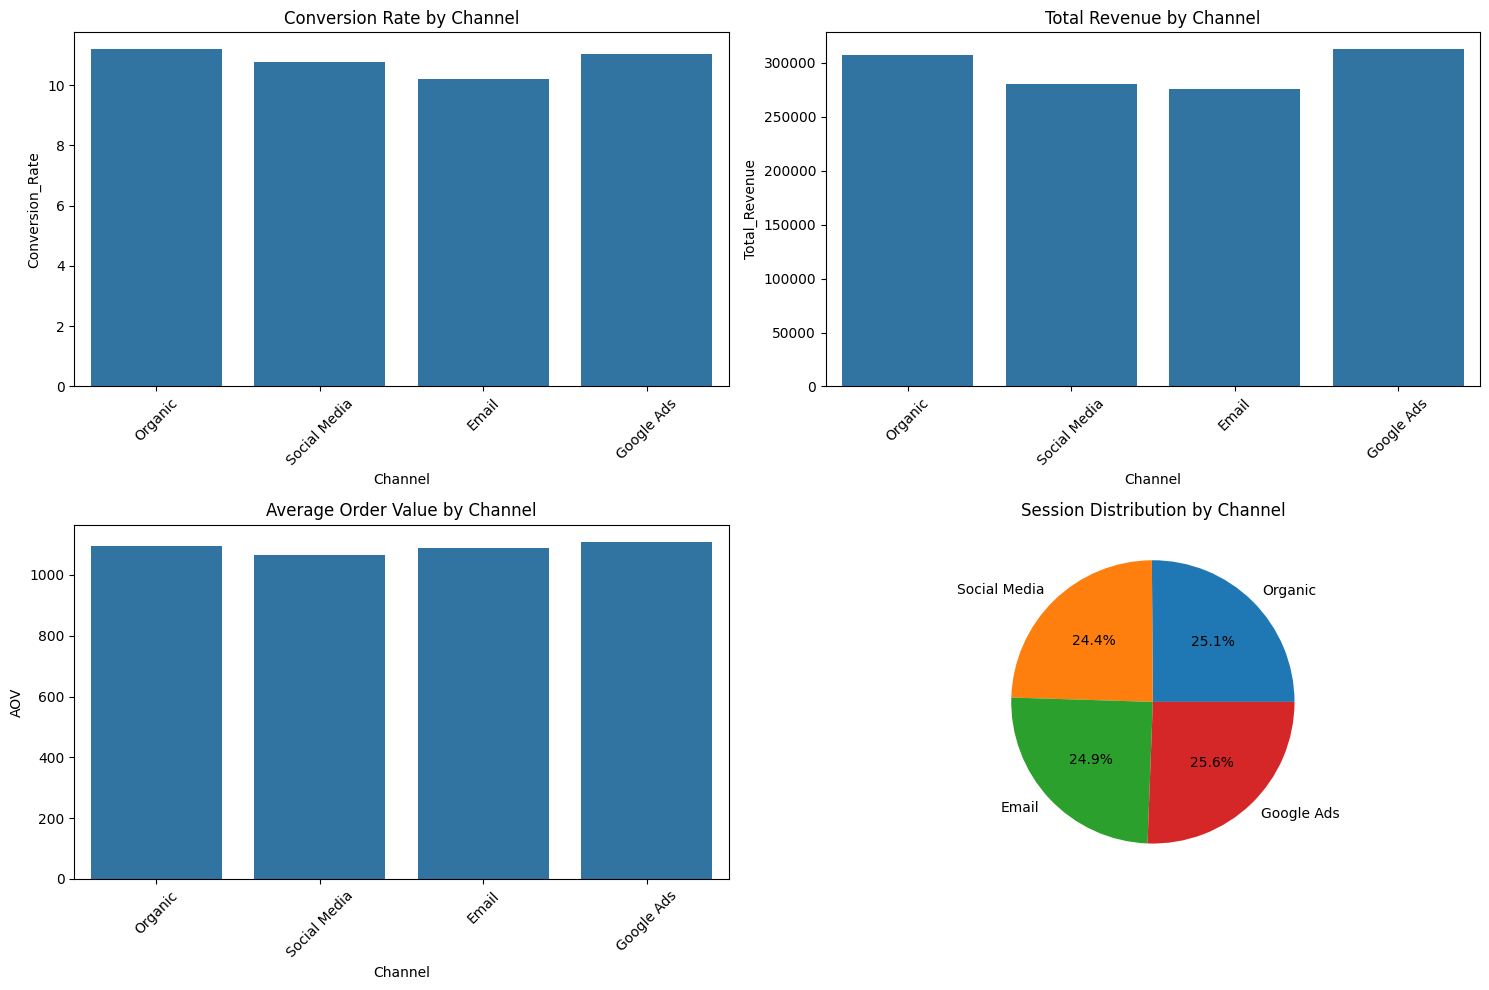

In [35]:
#channel performance analysis
# Funnel analysis by channel
channel_funnel = []

for channel in df['Channel'].unique():

    channel_sessions = session_summary[session_summary['Channel'] == channel]
    total_sessions = len(channel_sessions)

    if total_sessions > 0:

        channel_metrics = {
            'Channel': channel,
            'Total_Sessions': total_sessions
        }

        for i, stage in enumerate(funnel_stages):

            if i == 0:
                count = total_sessions
            else:
                count = len(
                    channel_sessions[
                        channel_sessions['Max_Funnel_Stage'].isin(funnel_stages[i:])
                    ]
                )

            channel_metrics[f'{stage}_Sessions'] = count
            channel_metrics[f'{stage}_Rate'] = (count / total_sessions * 100)

        # Revenue metrics
        purchase_sessions = channel_sessions[
            channel_sessions['Max_Funnel_Stage'] == 'Purchase'
        ]

        channel_metrics['Total_Revenue'] = purchase_sessions['Revenue'].sum()

        channel_metrics['AOV'] = (
            purchase_sessions['Revenue'].mean()
            if len(purchase_sessions) > 0 else 0
        )

        channel_metrics['Conversion_Rate'] = (
            len(purchase_sessions) / total_sessions * 100
        )

        channel_funnel.append(channel_metrics)
channel_df = pd.DataFrame(channel_funnel)

print("📊 Channel Performance Analysis:")
display(channel_df.round(2))

# Visualize channel performance
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Conversion rates by channel
sns.barplot(data=channel_df, x='Channel', y='Conversion_Rate', ax=ax1)
ax1.set_title('Conversion Rate by Channel')
ax1.tick_params(axis='x', rotation=45)

# Total revenue by channel
sns.barplot(data=channel_df, x='Channel', y='Total_Revenue', ax=ax2)
ax2.set_title('Total Revenue by Channel')
ax2.tick_params(axis='x', rotation=45)

# AOV by channel
sns.barplot(data=channel_df, x='Channel', y='AOV', ax=ax3)
ax3.set_title('Average Order Value by Channel')
ax3.tick_params(axis='x', rotation=45)

# Session distribution by channel
channel_df['Session_Percentage'] = (
    channel_df['Total_Sessions'] / channel_df['Total_Sessions'].sum()
) * 100

ax4.pie(
    channel_df['Session_Percentage'],
    labels=channel_df['Channel'],
    autopct='%1.1f%%'
)

ax4.set_title('Session Distribution by Channel')

plt.tight_layout()
plt.show()

Regional Performance:


,Total_Sessions,Total_Revenue,Session_Duration_Min,Converted_Sessions,Conversion_Rate,AOV
Region,,,,,,
East,2514,301767.14,4.146778,280,11.14,1077.74
North,2504,288027.95,3.998003,261,10.42,1103.56
South,2506,311018.57,4.102155,282,11.25,1102.90
West,2476,275592.12,4.080775,257,10.38,1072.34


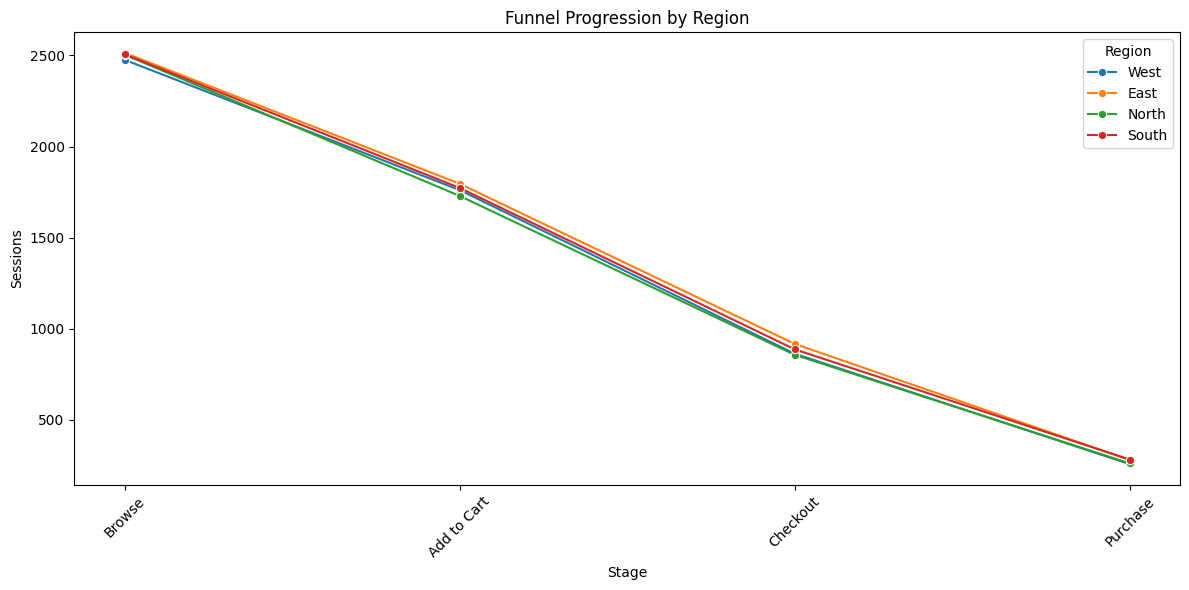

In [36]:
# Regional performance analysis
regional_analysis = session_summary.groupby('Region').agg({
    'Session_ID': 'count',
    'Revenue': 'sum',
    'Session_Duration_Min': 'mean'
}).rename(columns={
    'Session_ID': 'Total_Sessions',
    'Revenue': 'Total_Revenue'
})

# Add conversion rates by region
regional_conversion = session_summary[
    session_summary['Max_Funnel_Stage'] == 'Purchase'
].groupby('Region').size()

regional_analysis['Converted_Sessions'] = regional_conversion

regional_analysis['Conversion_Rate'] = (
    regional_analysis['Converted_Sessions'] /
    regional_analysis['Total_Sessions'] * 100
).round(2)

regional_analysis['AOV'] = (
    regional_analysis['Total_Revenue'] /
    regional_analysis['Converted_Sessions']
).round(2)

print("Regional Performance:")
display(regional_analysis)

# Regional funnel visualization
regional_funnel_data = []

for region in df['Region'].unique():

    region_sessions = session_summary[
        session_summary['Region'] == region
    ]

    for stage in funnel_stages:

        if stage == 'Browse':
            count = len(region_sessions)

        else:
            count = len(
                region_sessions[
                    region_sessions['Max_Funnel_Stage'].isin(
                        funnel_stages[funnel_stages.index(stage):]
                    )
                ]
            )

        regional_funnel_data.append({
            'Region': region,
            'Stage': stage,
            'Sessions': count
        })

regional_funnel_df = pd.DataFrame(regional_funnel_data)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=regional_funnel_df,
    x='Stage',
    y='Sessions',
    hue='Region',
    marker='o'
)

plt.title('Funnel Progression by Region')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

 Device Performance:


,Total_Sessions,Revenue,Session_Duration_Min,Purchases,Conversion_Rate,AOV
Device,,,,,,
Desktop,3331,399395.43,4.095167,372,11.17,1073.64
Mobile,3345,405451.84,4.061584,363,10.85,1116.95
Tablet,3324,371558.51,4.089350,345,10.38,1076.98


Product Category Performance:


,Total_Sessions,Revenue,Purchases,Conversion_Rate,AOV,Revenue_Per_Session
Product_Category,,,,,,
Beauty,1978,241834.97,226,11.43,1070.07,122.26
Electronics,2046,226451.63,208,10.17,1088.71,110.68
Fashion,2035,237261.50,220,10.81,1078.46,116.59
Home,1941,232534.83,211,10.87,1102.06,119.80
Sports,2000,238322.85,215,10.75,1108.48,119.16


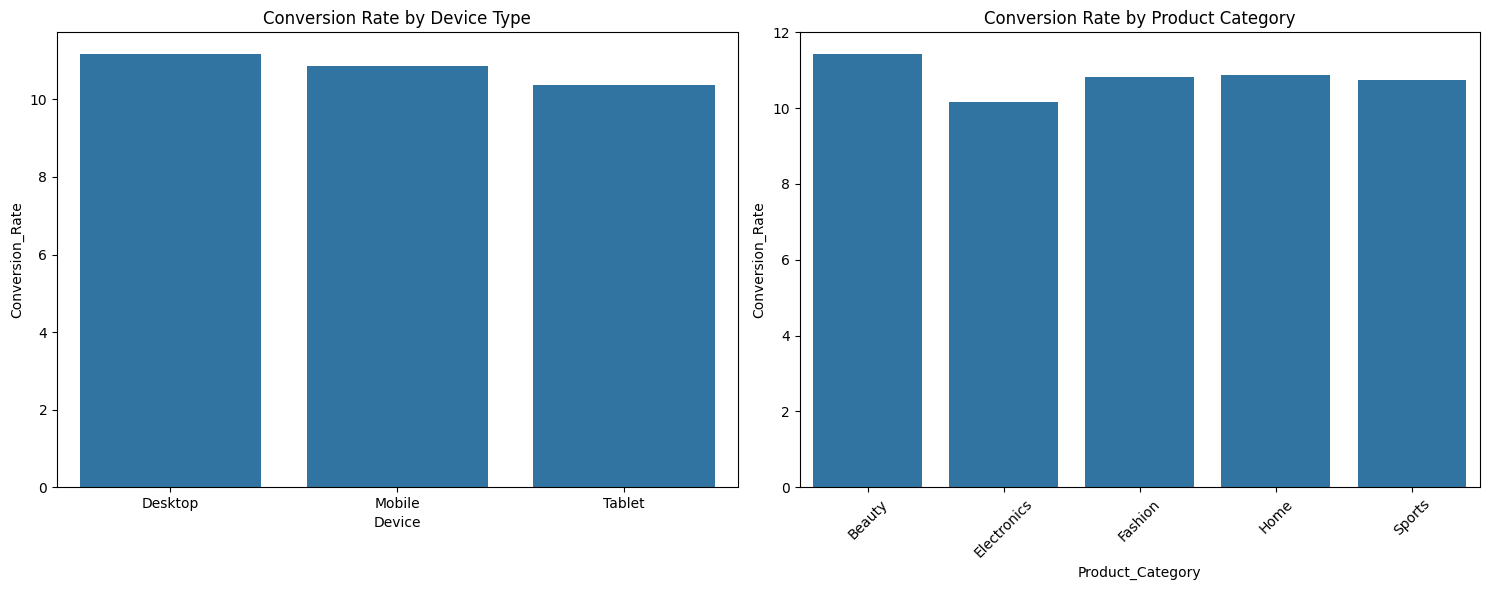

In [37]:
#device and product category analysis
# Device performance
device_analysis = session_summary.groupby('Device').agg({
    'Session_ID': 'count',
    'Revenue': 'sum',
    'Session_Duration_Min': 'mean',
    'Max_Funnel_Stage': lambda x: (x == 'Purchase').sum()
}).rename(columns={'Session_ID': 'Total_Sessions', 'Max_Funnel_Stage': 'Purchases'})

device_analysis['Conversion_Rate'] = (device_analysis['Purchases'] / device_analysis['Total_Sessions'] * 100).round(2)
device_analysis['AOV'] = (device_analysis['Revenue'] / device_analysis['Purchases']).round(2)

print(" Device Performance:")
display(device_analysis)

# Product category analysis
product_analysis = session_summary.groupby('Product_Category').agg({
    'Session_ID': 'count',
    'Revenue': 'sum',
    'Max_Funnel_Stage': lambda x: (x == 'Purchase').sum()
}).rename(columns={'Session_ID': 'Total_Sessions', 'Max_Funnel_Stage': 'Purchases'})

product_analysis['Conversion_Rate'] = (product_analysis['Purchases'] / product_analysis['Total_Sessions'] * 100).round(2)
product_analysis['AOV'] = (product_analysis['Revenue'] / product_analysis['Purchases']).round(2)
product_analysis['Revenue_Per_Session'] = (product_analysis['Revenue'] / product_analysis['Total_Sessions']).round(2)

print("Product Category Performance:")
display(product_analysis)

# Combined visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Device performance
sns.barplot(data=device_analysis.reset_index(), x='Device', y='Conversion_Rate', ax=ax1)
ax1.set_title('Conversion Rate by Device Type')

# Product category performance
sns.barplot(data=product_analysis.reset_index(), x='Product_Category', y='Conversion_Rate', ax=ax2)
ax2.set_title('Conversion Rate by Product Category')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


 Daily Performance Trends:


,Daily_Sessions,Daily_Users,Revenue,Daily_Conversions,Daily_Conversion_Rate
Date,,,,,
2025-10-22,300,300,33633.64,31,10.33
2025-10-23,347,347,50983.83,47,13.54
2025-10-24,315,315,39543.10,38,12.06
2025-10-25,364,364,50965.19,42,11.54
2025-10-26,355,355,42548.29,38,10.70
2025-10-27,310,310,41315.66,42,13.55
2025-10-28,347,347,39963.77,31,8.93
2025-10-29,336,336,29960.83,28,8.33
2025-10-30,331,331,35412.95,34,10.27


/tmp/ipykernel_1098/194966629.py:28: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Text(0.5, 0, 'Hour of Day')

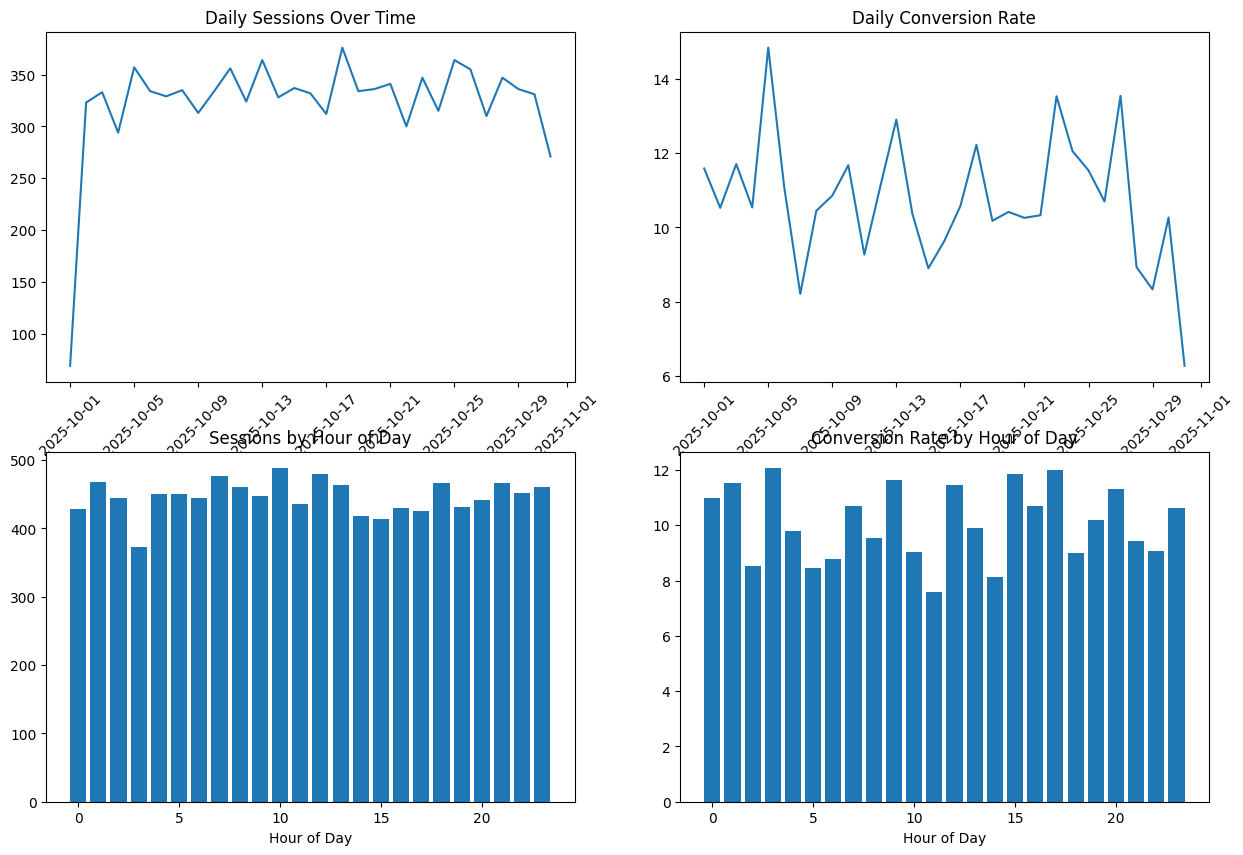

In [38]:
#time based analysis
# Daily trends
daily_metrics = df.groupby('Date').agg({
    'Session_ID': 'nunique',
    'User_ID': 'nunique',
    'Revenue': 'sum'
}).rename(columns={'Session_ID': 'Daily_Sessions', 'User_ID': 'Daily_Users'})

# Add conversion rates daily
# Modify the problematic line to extract date from datetime
daily_conversions = session_summary[session_summary['Max_Funnel_Stage'] == 'Purchase'].groupby(
    session_summary['Session_Start'].dt.date
).size()

daily_metrics['Daily_Conversions'] = daily_conversions
daily_metrics['Daily_Conversion_Rate'] = (daily_metrics['Daily_Conversions'] / daily_metrics['Daily_Sessions'] * 100).round(2)

print(" Daily Performance Trends:")
display(daily_metrics.tail(10))

# Hourly patterns
hourly_sessions = df.groupby('Hour').agg({
    'Session_ID': 'nunique',
    'Revenue': 'sum'
}).rename(columns={'Session_ID': 'Hourly_Sessions'})

hourly_conversions = session_summary[session_summary['Max_Funnel_Stage'] == 'Purchase']
hourly_conversions['Hour'] = hourly_conversions['Session_Start'].dt.hour
hourly_conversion_counts = hourly_conversions.groupby('Hour').size()
hourly_sessions['Hourly_Conversions'] = hourly_conversion_counts
hourly_sessions['Hourly_Conversion_Rate'] = (hourly_sessions['Hourly_Conversions'] / hourly_sessions['Hourly_Sessions'] * 100).round(2)

# Visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Daily sessions
ax1.plot(daily_metrics.index, daily_metrics['Daily_Sessions'])
ax1.set_title('Daily Sessions Over Time')
ax1.tick_params(axis='x', rotation=45)

# Daily conversion rate
ax2.plot(daily_metrics.index, daily_metrics['Daily_Conversion_Rate'])
ax2.set_title('Daily Conversion Rate')
ax2.tick_params(axis='x', rotation=45)

# Hourly session pattern
ax3.bar(hourly_sessions.index, hourly_sessions['Hourly_Sessions'])
ax3.set_title('Sessions by Hour of Day')
ax3.set_xlabel('Hour of Day')

# Hourly conversion rate
ax4.bar(hourly_sessions.index, hourly_sessions['Hourly_Conversion_Rate'])
ax4.set_title('Conversion Rate by Hour of Day')
ax4.set_xlabel('Hour of Day')

In [39]:
# Calculate advanced metrics
print(" KEY PERFORMANCE INDICATORS (KPIs)")
print("="*50)

# Overall KPIs
total_sessions = len(session_summary)
total_revenue = session_summary['Revenue'].sum()
total_orders = len(session_summary[session_summary['Max_Funnel_Stage'] == 'Purchase'])
overall_conversion_rate = (total_orders / total_sessions * 100)

print(f"📈 Overall Conversion Rate: {overall_conversion_rate:.2f}%")
print(f"💰 Total Revenue: ${total_revenue:,.2f}")
print(f"🛒 Average Order Value: ${ (total_revenue/total_orders):.2f}")
print(f"👥 Total Sessions: {total_sessions:,}")
print(f"🎯 Total Orders: {total_orders:,}")

# Funnel efficiency metrics
browse_to_cart = (funnel_df.iloc[1]['Sessions'] / funnel_df.iloc[0]['Sessions'] * 100)
cart_to_checkout = (funnel_df.iloc[2]['Sessions'] / funnel_df.iloc[1]['Sessions'] * 100)
checkout_to_purchase = (funnel_df.iloc[3]['Sessions'] / funnel_df.iloc[2]['Sessions'] * 100)

print(f"\n Stage-to-Stage Conversion Rates:")
print(f"      Browse -> Add to Cart: {browse_to_cart:.2f}%")
print(f"      Add to Cart -> Checkout: {cart_to_checkout:.2f}%")
print(f"      Checkout -> Purchase: {checkout_to_purchase:.2f}%")



 KEY PERFORMANCE INDICATORS (KPIs)
📈 Overall Conversion Rate: 10.80%
💰 Total Revenue: $1,176,405.78
🛒 Average Order Value: $1089.26
👥 Total Sessions: 10,000
🎯 Total Orders: 1,080

 Stage-to-Stage Conversion Rates:
      Browse -> Add to Cart: 70.59%
      Add to Cart -> Checkout: 49.92%
      Checkout -> Purchase: 30.65%


In [40]:
# Revenue per session at each stage
revenue_per_browse = total_revenue / funnel_df.iloc[0]['Sessions']
revenue_per_cart = total_revenue / funnel_df.iloc[1]['Sessions']
revenue_per_checkout = total_revenue / funnel_df.iloc[2]['Sessions']

print(f"\n💸 Revenue per Session by Stage:")
print(f"      Per Browse Session: ${revenue_per_browse:.2f}")
print(f"      Per Cart Session: ${revenue_per_cart:.2f}")
print(f"      Per Checkout Session: ${revenue_per_checkout:.2f}")

# Bounce rate analysis
bounce_sessions = session_summary[session_summary['Bounce_Flag'] == 'Yes']
bounce_rate = (len(bounce_sessions) / total_sessions * 100)
print(f"\n📉 Bounce Rate: {bounce_rate:.2f}%")

# Session duration analysis
avg_session_duration = session_summary['Session_Duration_Min'].mean()
print(f"\n⏱️ Average Session Duration: {avg_session_duration:.2f} minutes")


💸 Revenue per Session by Stage:
      Per Browse Session: $117.64
      Per Cart Session: $166.65
      Per Checkout Session: $333.83

📉 Bounce Rate: 89.20%

⏱️ Average Session Duration: 4.08 minutes


In [41]:
# Generate actionable insights
print("🎯 STRATEGIC RECOMMENDATIONS")
print("="*50)

# Identify biggest drop-off points
max_dropoff_stage = funnel_df.loc[funnel_df['Drop_Off_Rate'].idxmax()]
print(f"🚨 BIGGEST DROP-OFF: {max_dropoff_stage['Stage']} stage with {max_dropoff_stage['Drop_Off_Rate']}% drop-off")

# Best performing channel
best_channel = channel_df.loc[channel_df['Conversion_Rate'].idxmax()]
print(f"🏆 BEST PERFORMING CHANNEL: {best_channel['Channel']} with {best_channel['Conversion_Rate']}% conversion")

# Best performing region
best_region = regional_analysis.loc[regional_analysis['Conversion_Rate'].idxmax()]
print(f"🌍 BEST PERFORMING REGION: {best_region.name} with {best_region['Conversion_Rate']}% conversion")

# Best performing product category
best_category = product_analysis.loc[product_analysis['Conversion_Rate'].idxmax()]
print(f"🏷️ BEST PERFORMING CATEGORY: {best_category.name} with {best_category['Conversion_Rate']}% conversion")

print(f"\n💡 RECOMMENDED ACTIONS:")
print(f"1. Address {max_dropoff_stage['Stage']} stage drop-off through UX improvements")
print(f"2. Allocate more budget to {best_channel['Channel']} channel")
print(f"3. Replicate {best_region.name} region strategies in underperforming regions")
print(f"4. Promote {best_category.name} category to improve overall conversion")
print(f"5. Focus on cart abandonment recovery for {funnel_df.iloc[2]['Drop_Off_Rate']}% of users")

# Calculate potential revenue opportunities
cart_abandonment_opportunity = funnel_df.iloc[2]['Sessions'] * product_analysis['AOV'].mean()
print(f"\n💡 RECOMMENDED ACTIONS:")
print(f"1. Address {max_dropoff_stage['Stage']} stage drop-off through UX improvements")
print(f"2. Allocate more budget to {best_channel['Channel']} channel")
print(f"3. Replicate {best_region.name} region strategies in underperforming regions")
print(f"4. Promote {best_category.name} category to improve overall conversion")
print(f"5. Focus on cart abandonment recovery for {funnel_df.iloc[2]['Drop_Off_Rate']}% of users")

# Calculate potential revenue opportunities
cart_abandonment_opportunity = funnel_df.iloc[2]['Sessions'] * product_analysis['AOV'].mean()
print(f"\n💰 REVENUE OPPORTUNITY:")
print(f"      Cart abandonment recovery: ${cart_abandonment_opportunity:,.2f} potential revenue")


🎯 STRATEGIC RECOMMENDATIONS
🚨 BIGGEST DROP-OFF: Purchase stage with 69.35% drop-off
🏆 BEST PERFORMING CHANNEL: Organic with 11.190760653126244% conversion
🌍 BEST PERFORMING REGION: South with 11.25% conversion
🏷️ BEST PERFORMING CATEGORY: Beauty with 11.43% conversion

💡 RECOMMENDED ACTIONS:
1. Address Purchase stage drop-off through UX improvements
2. Allocate more budget to Organic channel
3. Replicate South region strategies in underperforming regions
4. Promote Beauty category to improve overall conversion
5. Focus on cart abandonment recovery for 50.08% of users

💡 RECOMMENDED ACTIONS:
1. Address Purchase stage drop-off through UX improvements
2. Allocate more budget to Organic channel
3. Replicate South region strategies in underperforming regions
4. Promote Beauty category to improve overall conversion
5. Focus on cart abandonment recovery for 50.08% of users

💰 REVENUE OPPORTUNITY:
      Cart abandonment recovery: $3,839,595.34 potential revenue


✅ Analysis complete! Report exported to 'funnel_analysis_report.xlsx'
✅ Key visualizations saved!


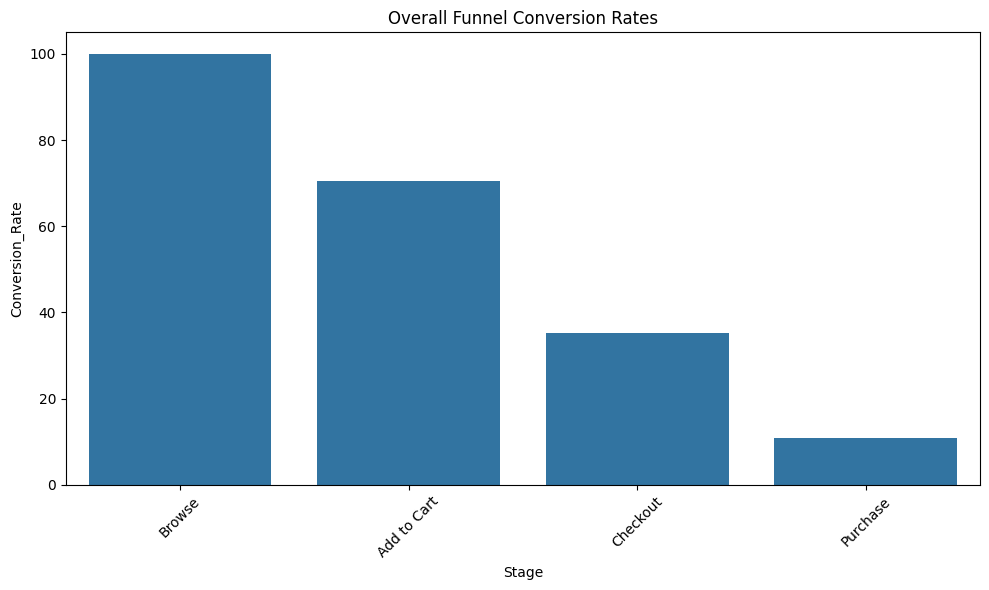

In [42]:
# Create comprehensive report
report_data = {
    'Overall_Funnel': funnel_df,
    'Channel_Performance': channel_df,
    'Regional_Analysis': regional_analysis,
    'Device_Performance': device_analysis,
    'Product_Performance': product_analysis,
    'Daily_Trends': daily_metrics,
    'Hourly_Patterns': hourly_sessions
}

# Export to Excel for corporate reporting
with pd.ExcelWriter('funnel_analysis_report.xlsx') as writer:
    for sheet_name, data in report_data.items():
        data.to_excel(writer, sheet_name=sheet_name, index=False)

print("✅ Analysis complete! Report exported to 'funnel_analysis_report.xlsx'")

# Save key visualizations
plt.figure(figsize=(10, 6))
sns.barplot(data=funnel_df, x='Stage', y='Conversion_Rate')
plt.title('Overall Funnel Conversion Rates')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('funnel_conversion_rates.png', dpi=300, bbox_inches='tight')

print("✅ Key visualizations saved!")